In [30]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import astropy.units as u

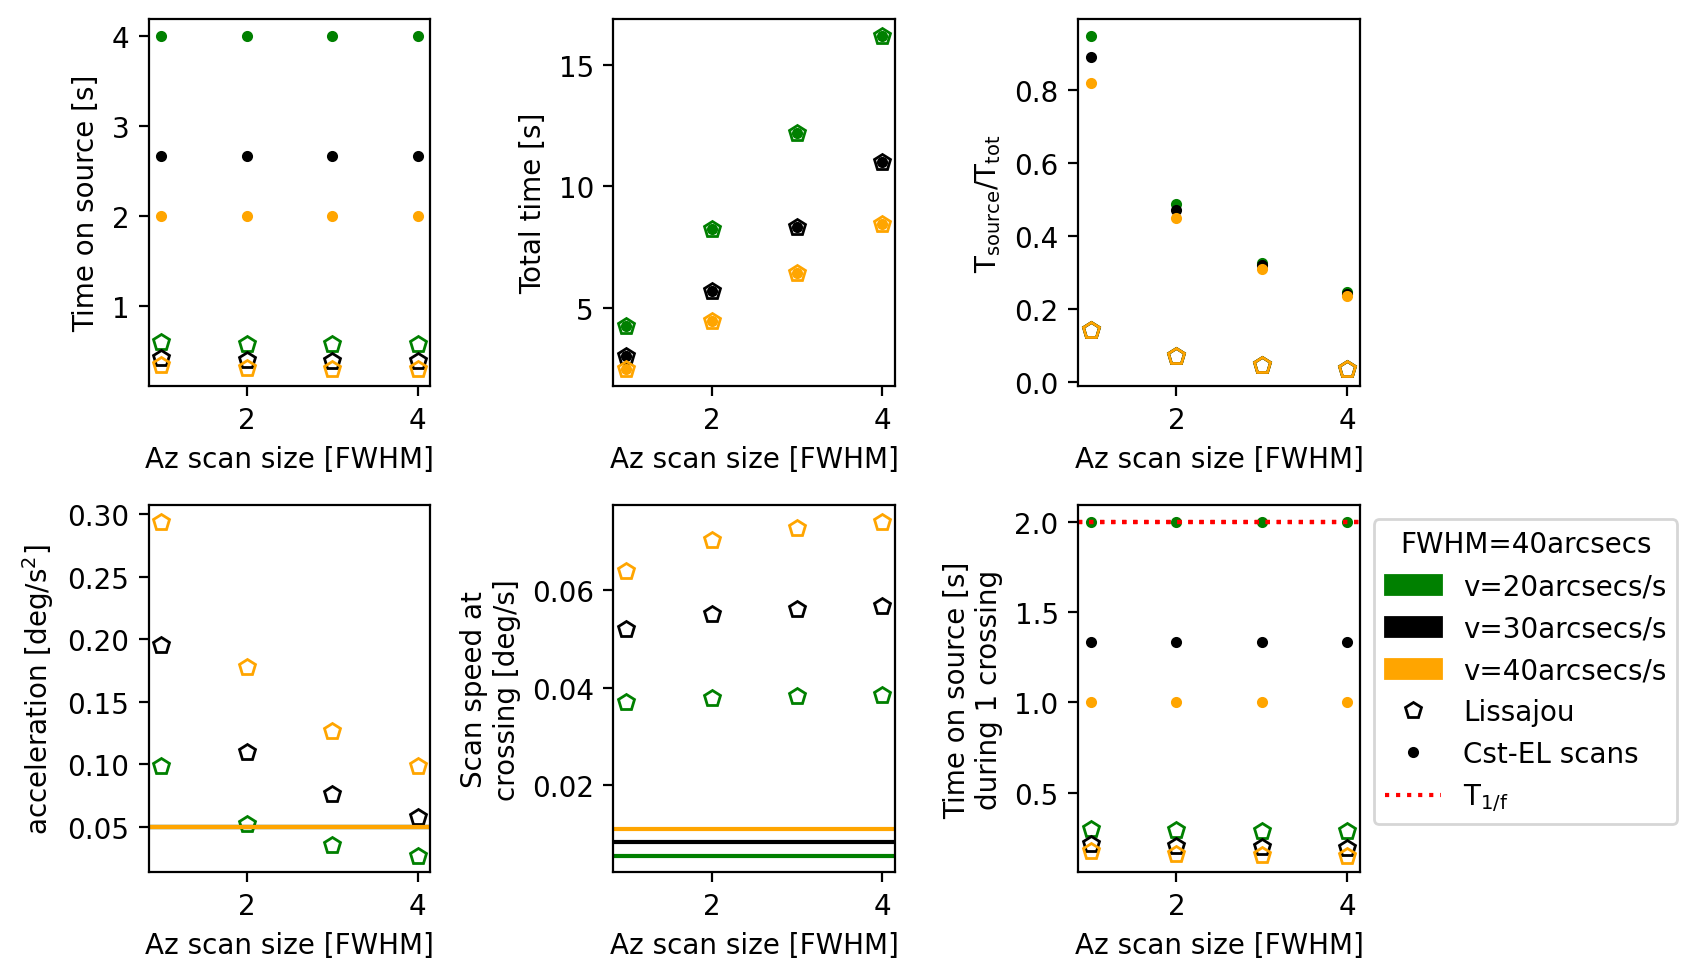

In [31]:
acc = 0.05 #deg/s^2
acc_arcsec_s2 = acc * 3600 
scan_speed_list = np.array((20,30,40)) #arcsecs/s
fwhm = 40 #arcsecs
field_size_in_fwhm = np.array((1,2,3,4))
f_oneoverf_knee = 0.5 #Hz

fig, axs = plt.subplots(2,3,figsize=(7,5),dpi=200)
axs = axs.ravel()
patchs = []
for v, c in zip(scan_speed_list, ('g', 'k', 'orange')):
    patch = mpatches.Patch(color=c, label= f'v={v:.0f}arcsecs/s'); patchs.append(patch)

    T_onsource  = 2*fwhm/v
    Ttot_azscan = 2*( (field_size_in_fwhm*fwhm)/v + v/acc_arcsec_s2 )
    f = T_onsource/Ttot_azscan

    axs[0].plot(field_size_in_fwhm, T_onsource*np.ones(len(field_size_in_fwhm)), '.', c=c)
    axs[5].plot(field_size_in_fwhm, T_onsource/2*np.ones(len(field_size_in_fwhm)), '.', c=c)
    axs[5].axhline(1/f_oneoverf_knee, c='r', ls=':')

    axs[1].plot(field_size_in_fwhm, Ttot_azscan, '.', c=c)
    axs[2].plot(field_size_in_fwhm, f, '.', c=c)
    axs[3].axhline(acc, c=c)
    axs[4].axhline(v/3600, c=c)

    lissajou_period = Ttot_azscan
    angular_frequency = 2 * np.pi / lissajou_period
    A =( (field_size_in_fwhm*fwhm) *u.arcsec).to(u.rad)

    for B_factor in (1,):

        B = B_factor * A
        vcross = angular_frequency * np.sqrt(A**2+4*B**2)
        T_onsource_lissajou = 2 * (fwhm*u.arcsec).to(u.rad) / vcross
        axs[5].plot(field_size_in_fwhm, T_onsource_lissajou/2, marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)

        f_lissajou = T_onsource_lissajou / lissajou_period
        axs[0].plot(field_size_in_fwhm, T_onsource_lissajou, marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        axs[1].plot(field_size_in_fwhm, lissajou_period, marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        axs[2].plot(field_size_in_fwhm, f_lissajou, marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        acc_lissajou = np.rad2deg(4 * B * angular_frequency**2)
        axs[3].plot(field_size_in_fwhm, acc_lissajou,
                     marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        
        vcross_deg_per_second = np.rad2deg(vcross)
        axs[4].plot(field_size_in_fwhm,vcross_deg_per_second,marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        

patch = mlines.Line2D([], [], ls='None', markerfacecolor='none',markeredgecolor='k', marker='p', label="Lissajou"); patchs.append(patch)
patch = mlines.Line2D([], [], ls='None', marker='.', color='k', label="Cst-EL scans"); patchs.append(patch)
patch = mlines.Line2D([], [], ls=':', color='r', label="$\\rm T_{1/f}$"); patchs.append(patch)

axs[0].set_xlabel('Az scan size [FWHM]')
axs[1].set_xlabel('Az scan size [FWHM]')
axs[2].set_xlabel('Az scan size [FWHM]')
axs[3].set_xlabel('Az scan size [FWHM]')
axs[4].set_xlabel('Az scan size [FWHM]')
axs[5].set_xlabel('Az scan size [FWHM]')

axs[0].set_ylabel('Time on source [s]')
axs[1].set_ylabel('Total time [s]')
axs[4].set_ylabel('Scan speed at\ncrossing [deg/s]')
axs[5].set_ylabel('Time on source [s]\nduring 1 crossing')

axs[2].set_ylabel('$\\rm T_{source}/T_{tot}$')
axs[3].set_ylabel('acceleration [$\\rm deg/s^2$]')
fig.tight_layout()

axs[-1].legend(title=f'FWHM={fwhm:.0f}arcsecs',handles=patchs,bbox_to_anchor=(1,1))


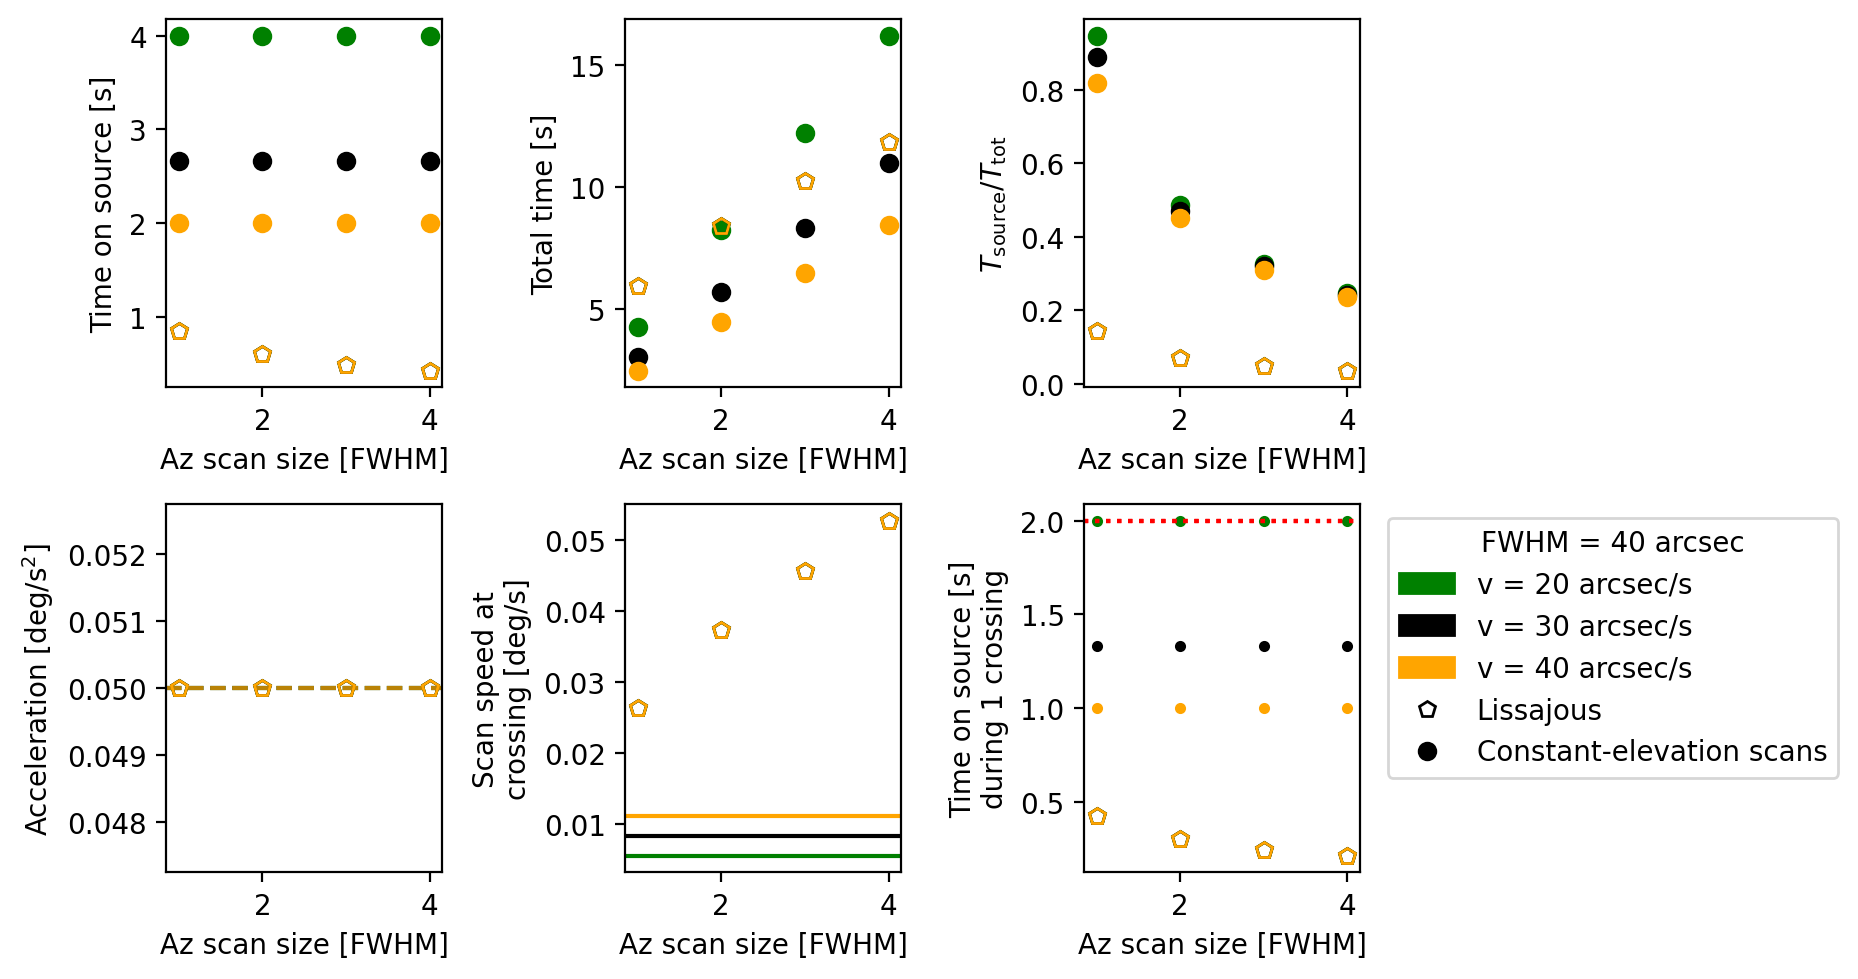

In [32]:

# Maximum allowed angular acceleration
acc_deg_s2 = 0.05
acc_rad_s2 = np.deg2rad(acc_deg_s2)

# Constant-elevation scan acceleration in arcsec/s^2
acc_arcsec_s2 = acc_deg_s2 * 3600.0

# Scan parameters
scan_speed_list = np.array([20.0, 30.0, 40.0])  # arcsec/s
fwhm = 40.0                                      # arcsec
field_size_in_fwhm = np.array([1, 2, 3, 4])


fig, axs = plt.subplots(2,3,figsize=(7,5),dpi=200)
axs = axs.ravel()

patchs = []

axs[4].set_xlabel('Az scan size [FWHM]')
axs[4].set_ylabel('Scan speed at\ncrossing [deg/s]')
axs[5].set_xlabel('Az scan size [FWHM]')
axs[5].set_ylabel('Time on source [s]\nduring 1 crossing')

for v, c in zip(scan_speed_list, ('g', 'k', 'orange')):

    axs[4].axhline(v/3600, c=c)

    # Constant-elevation scan
    Ttot_azscan = 2.0 * ((field_size_in_fwhm * fwhm) / v+ v / acc_arcsec_s2)  # seconds

    T_onsource = 2.0 * fwhm / v  # seconds

    axs[5].plot(field_size_in_fwhm, T_onsource/2*np.ones(len(field_size_in_fwhm)), '.', c=c)
    axs[5].axhline(1/f_oneoverf_knee, c='r', ls=':')

    f_azscan = T_onsource / Ttot_azscan
    axs[0].plot(field_size_in_fwhm,T_onsource * np.ones_like(field_size_in_fwhm),marker='o',linestyle='None', c=c)
    axs[1].plot(field_size_in_fwhm,Ttot_azscan,marker='o',linestyle='None', c=c)
    line = axs[2].plot(field_size_in_fwhm,f_azscan,marker='o',linestyle='None', c=c)[0]
    c = line.get_color()
    # Constant-elevation acceleration reference
    axs[3].axhline(acc_deg_s2,color=c,linestyle='--',alpha=0.7, c=c)
    # Convert scan amplitude from arcsec to radians
    A = (field_size_in_fwhm * fwhm * u.arcsec).to_value(u.rad)

    for B_factor in (1.0,):

        # Lissajous amplitude in radians
        B = B_factor * A

        angular_frequency = np.sqrt(acc_rad_s2 / np.maximum(A, 4 * B))  # 1/s
        lissajou_period = 2*np.pi/angular_frequency
        
        acc_x_rad_s2 = A * angular_frequency**2
        acc_y_rad_s2 = 4.0 * B * angular_frequency**2
        acc_lissajou_rad_s2 = np.maximum(acc_x_rad_s2,acc_y_rad_s2)

        acc_lissajou_deg_s2 = np.rad2deg(acc_lissajou_rad_s2)
        # Maximum scan speed along the Lissajous trajectory
        v_lissajou = (angular_frequency* np.sqrt(A**2 + 4.0 * B**2))  # rad/s
        # Time spent within one beam crossing
        beam_rad = (fwhm * u.arcsec).to_value(u.rad)
        T_onsource_lissajou = (2.0 * beam_rad / v_lissajou)  # seconds
        f_lissajou = (T_onsource_lissajou / lissajou_period)
        # Time on source
        axs[0].plot(field_size_in_fwhm,T_onsource_lissajou,marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        # Total Lissajous period
        axs[1].plot(field_size_in_fwhm,lissajou_period,marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        # Fraction of time on source
        axs[2].plot(field_size_in_fwhm,f_lissajou,marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        # Lissajous maximum acceleration
        axs[3].plot(field_size_in_fwhm,acc_lissajou_deg_s2,marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)

        vcross_deg_per_second = np.rad2deg(v_lissajou)
        axs[4].plot(field_size_in_fwhm,vcross_deg_per_second,marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)
        axs[5].plot(field_size_in_fwhm, T_onsource_lissajou/2, marker='p',linestyle='None',markerfacecolor='none',markeredgecolor=c)


    patchs.append(mpatches.Patch(color=c,label=f'v = {v:.0f} arcsec/s'))

# Legend entries
patchs.append(mlines.Line2D([], [],linestyle='None',marker='p',markerfacecolor='none',markeredgecolor='k',label='Lissajous'))
patchs.append(mlines.Line2D([], [],linestyle='None',marker='o',color='k',label='Constant-elevation scans'))

# Labels
axs[0].set_xlabel('Az scan size [FWHM]')
axs[1].set_xlabel('Az scan size [FWHM]')
axs[2].set_xlabel('Az scan size [FWHM]')
axs[3].set_xlabel('Az scan size [FWHM]')

axs[0].set_ylabel('Time on source [s]')
axs[1].set_ylabel('Total time [s]')
axs[2].set_ylabel(r'$T_{\rm source}/T_{\rm tot}$')
axs[3].set_ylabel(r'Acceleration [$\mathrm{deg/s^2}$]')

fig.tight_layout()

axs[-1].legend(title=f'FWHM = {fwhm:.0f} arcsec',handles=patchs,bbox_to_anchor=(1.05, 1.0),loc='upper left')


In [4]:
np.diff(time).mean()

0.03324584426946632

Scan range        = [-80.0, 80.0] arcsec
Maximum speed     = 40.0 arcsec/s
Acceleration      = 180.0 arcsec/s^2
One-way time      = 4.222 s
Full scan period  = 8.444 s


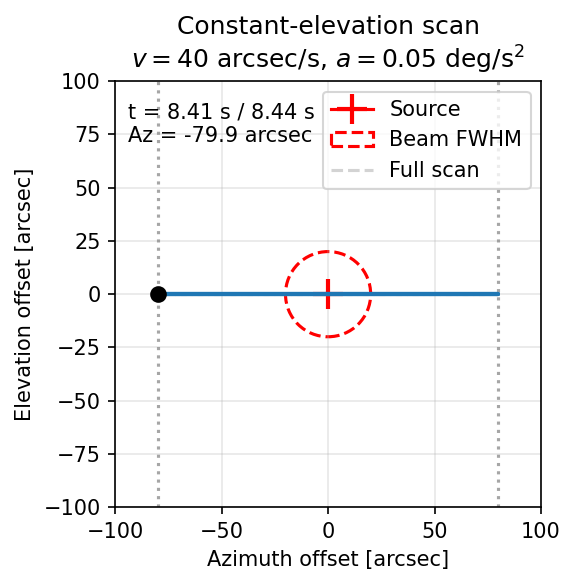

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle

# ============================================================
# Parameters
# ============================================================
acc_deg_s2 = 0.05
acc_arcsec_s2 = acc_deg_s2 * 3600.0  # arcsec/s^2

v = 40.0          # arcsec/s
fwhm = 40.0       # arcsec

# Scan range: -2 FWHM to +2 FWHM
x_min = -2.0 * fwhm
x_max = +2.0 * fwhm
scan_distance = x_max - x_min

# ============================================================
# Scan timing
# ============================================================
t_acc = v / acc_arcsec_s2
d_acc = 0.5 * acc_arcsec_s2 * t_acc**2

# Distance travelled during acceleration and deceleration
d_acc_total = 2.0 * d_acc

if d_acc_total < scan_distance:
    # Trapezoidal velocity profile
    t_const = (scan_distance - d_acc_total) / v
    t_half = 2.0 * t_acc + t_const
else:
    # Triangular velocity profile
    t_acc = np.sqrt(scan_distance / acc_arcsec_s2)
    t_const = 0.0
    t_half = 2.0 * t_acc

period = 2.0 * t_half

print(f"Scan range        = [{x_min:.1f}, {x_max:.1f}] arcsec")
print(f"Maximum speed     = {v:.1f} arcsec/s")
print(f"Acceleration      = {acc_arcsec_s2:.1f} arcsec/s^2")
print(f"One-way time      = {t_half:.3f} s")
print(f"Full scan period  = {period:.3f} s")

# ============================================================
# Time sampling
# ============================================================
fps = 30
n_frames = int(np.ceil(fps * period))
time = np.linspace(0.0, period, n_frames, endpoint=False)


# ============================================================
# Scan timing
# ============================================================
t_acc = v / acc_arcsec_s2
d_acc = 0.5 * acc_arcsec_s2 * t_acc**2

if 2.0 * d_acc < scan_distance:
    # Trapezoidal velocity profile
    t_const = (scan_distance - 2.0 * d_acc) / v
else:
    # Triangular velocity profile
    t_acc = np.sqrt(scan_distance / acc_arcsec_s2)
    d_acc = 0.5 * acc_arcsec_s2 * t_acc**2
    t_const = 0.0

t_half = 2.0 * t_acc + t_const
period = 2.0 * t_half

# ============================================================
# Forward scan: x_min -> x_max
# ============================================================
def forward_position(t):
    x = np.empty_like(t)

    # Acceleration: v = 0 -> v
    mask_acc = t < t_acc
    x[mask_acc] = (
        x_min
        + 0.5 * acc_arcsec_s2 * t[mask_acc]**2
    )

    # Constant velocity
    mask_const = (
        (t >= t_acc)
        & (t < t_acc + t_const)
    )

    x[mask_const] = (
        x_min
        + d_acc
        + v * (t[mask_const] - t_acc)
    )

    # Deceleration: v -> 0
    mask_dec = t >= t_acc + t_const
    tau = t[mask_dec] - t_acc - t_const

    x_start_dec = x_max - d_acc

    x[mask_dec] = (
        x_start_dec
        + v * tau
        - 0.5 * acc_arcsec_s2 * tau**2
    )

    return x


# ============================================================
# Complete back-and-forth scan
# ============================================================
x_cst_el = np.empty_like(time)

# Forward scan: x_min -> x_max
mask_forward = time < t_half
x_cst_el[mask_forward] = forward_position(
    time[mask_forward]
)

# Backward scan: x_max -> x_min
mask_backward = ~mask_forward
t_backward = time[mask_backward] - t_half

x_forward = forward_position(t_backward)

# Reflect the forward trajectory around the center
x_cst_el[mask_backward] = (
    x_min + x_max - x_forward
)

# Constant elevation
y_cst_el = np.zeros_like(x_cst_el)

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

plot_limit = 2.5 * fwhm

ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)
ax.set_aspect("equal")

ax.set_xlabel("Azimuth offset [arcsec]")
ax.set_ylabel("Elevation offset [arcsec]")
ax.set_title(
    "Constant-elevation scan\n"
    rf"$v={v:.0f}$ arcsec/s, "
    rf"$a={acc_deg_s2:.2f}$ deg/s$^2$"
)

ax.grid(alpha=0.3)

# Source position
ax.plot(
    0.0,
    0.0,
    marker="+",
    color="red",
    markersize=14,
    markeredgewidth=2,
    label="Source"
)

# Beam centered at (0, 0)
beam = Circle(
    (0.0, 0.0),
    radius=fwhm / 2.0,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
    linewidth=1.5,
    label="Beam FWHM"
)
ax.add_patch(beam)

# Scan limits
ax.axvline(x_min, color="gray", linestyle=":", alpha=0.7)
ax.axvline(x_max, color="gray", linestyle=":", alpha=0.7)

# Full scan path
ax.plot(
    x_cst_el,
    y_cst_el,
    color="lightgray",
    linestyle="--",
    label="Full scan"
)

# Animated trail and telescope position
trail, = ax.plot(
    [],
    [],
    color="tab:blue",
    linewidth=2
)

point, = ax.plot(
    [],
    [],
    marker="o",
    color="black",
    markersize=7
)

time_text = ax.text(
    0.03,
    0.95,
    "",
    transform=ax.transAxes,
    verticalalignment="top"
)

ax.legend(loc="upper right")

fig.tight_layout()

# ============================================================
# Animation
# ============================================================
def init():
    trail.set_data([], [])
    point.set_data([], [])
    time_text.set_text("")
    return trail, point, time_text


def update(frame):
    trail.set_data(
        x_cst_el[:frame + 1],
        y_cst_el[:frame + 1]
    )

    point.set_data(
        [x_cst_el[frame]],
        [y_cst_el[frame]]
    )

    time_text.set_text(
        f"t = {time[frame]:.2f} s / {period:.2f} s\n"
        f"Az = {x_cst_el[frame]:.1f} arcsec"
    )

    return trail, point, time_text


animation = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    init_func=init,
    interval=1000 / fps,
    blit=True
)

# Save GIF
animation.save(
    "constant_elevation_scan_centered.gif",
    writer=PillowWriter(fps=fps)
)

plt.show()

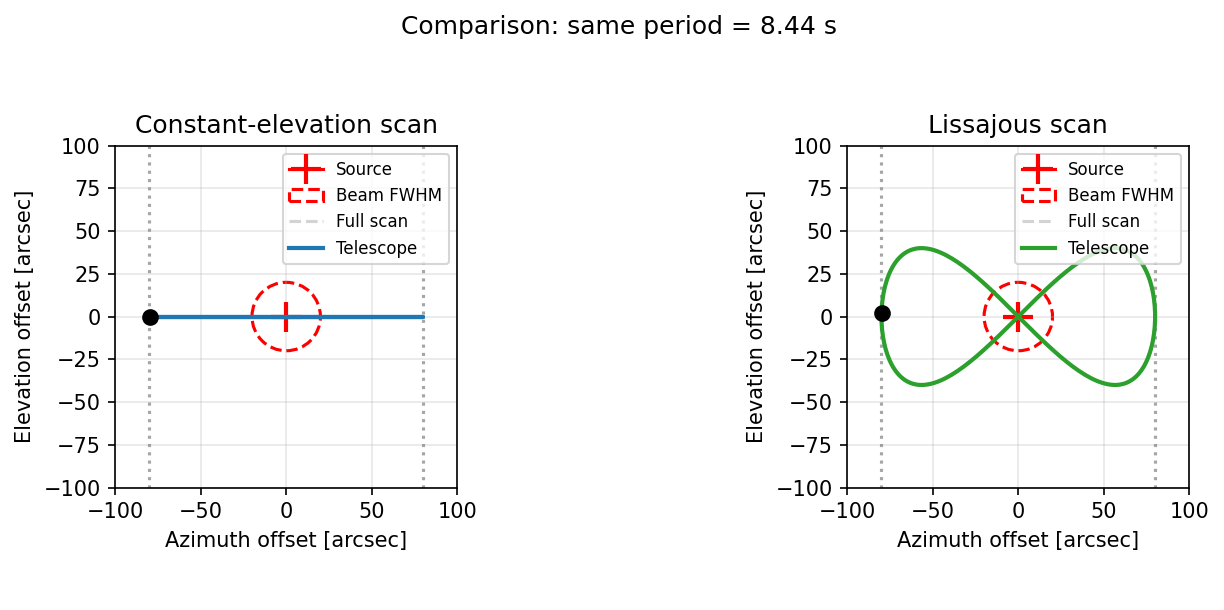

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle

# ============================================================
# Parameters
# ============================================================
acc_deg_s2 = 0.05
acc_arcsec_s2 = acc_deg_s2 * 3600.0

v = 40.0          # arcsec/s
fwhm = 40.0       # arcsec
field_size_in_fwhm = 2.0

# Scan range: -2 FWHM to +2 FWHM
x_min = -field_size_in_fwhm * fwhm
x_max = +field_size_in_fwhm * fwhm
scan_distance = x_max - x_min

# Lissajous amplitudes
A_arcsec = field_size_in_fwhm * fwhm
B_arcsec = A_arcsec / 2


# ============================================================
# Scan timing
# ============================================================
t_acc = v / acc_arcsec_s2
d_acc = 0.5 * acc_arcsec_s2 * t_acc**2

if 2.0 * d_acc < scan_distance:
    # Trapezoidal velocity profile
    t_const = (scan_distance - 2.0 * d_acc) / v
else:
    # Triangular velocity profile
    t_acc = np.sqrt(scan_distance / acc_arcsec_s2)
    d_acc = 0.5 * acc_arcsec_s2 * t_acc**2
    t_const = 0.0

t_half = 2.0 * t_acc + t_const
period = 2.0 * t_half

# ============================================================
# Forward scan: x_min -> x_max
# ============================================================
def forward_position(t):
    x = np.empty_like(t)

    # Acceleration: v = 0 -> v
    mask_acc = t < t_acc
    x[mask_acc] = (
        x_min
        + 0.5 * acc_arcsec_s2 * t[mask_acc]**2
    )

    # Constant velocity
    mask_const = (
        (t >= t_acc)
        & (t < t_acc + t_const)
    )

    x[mask_const] = (
        x_min
        + d_acc
        + v * (t[mask_const] - t_acc)
    )

    # Deceleration: v -> 0
    mask_dec = t >= t_acc + t_const
    tau = t[mask_dec] - t_acc - t_const

    x_start_dec = x_max - d_acc

    x[mask_dec] = (
        x_start_dec
        + v * tau
        - 0.5 * acc_arcsec_s2 * tau**2
    )

    return x


# ============================================================
# Complete back-and-forth scan
# ============================================================
x_cst_el = np.empty_like(time)

# Forward scan: x_min -> x_max
mask_forward = time < t_half
x_cst_el[mask_forward] = forward_position(
    time[mask_forward]
)

# Backward scan: x_max -> x_min
mask_backward = ~mask_forward
t_backward = time[mask_backward] - t_half

x_forward = forward_position(t_backward)

# Reflect the forward trajectory around the center
x_cst_el[mask_backward] = (
    x_min + x_max - x_forward
)

# Constant elevation
y_cst_el = np.zeros_like(x_cst_el)

# ============================================================
# Lissajous scan with the same period
# ============================================================
omega = 2.0 * np.pi / period

# Start at (-A, 0), matching the constant-elevation scan
x_lissajou = A_arcsec * np.sin(omega * time - np.pi / 2.0)
y_lissajou = B_arcsec * np.sin(2.0 * omega * time - np.pi)

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    dpi=150
)

plot_limit = 2.5 * fwhm

for ax in axes:
    ax.set_xlim(-plot_limit, plot_limit)
    ax.set_ylim(-plot_limit, plot_limit)
    ax.set_aspect("equal")
    ax.set_xlabel("Azimuth offset [arcsec]")
    ax.set_ylabel("Elevation offset [arcsec]")
    ax.grid(alpha=0.3)

# ------------------------------------------------------------
# Constant-elevation panel
# ------------------------------------------------------------
ax_cst = axes[0]
ax_cst.set_title("Constant-elevation scan")

# ------------------------------------------------------------
# Lissajous panel
# ------------------------------------------------------------
ax_liss = axes[1]
ax_liss.set_title("Lissajous scan")

for ax in axes:

    # Source
    ax.plot(
        0.0,
        0.0,
        marker="+",
        color="red",
        markersize=14,
        markeredgewidth=2,
        label="Source"
    )

    # Beam
    beam = Circle(
        (0.0, 0.0),
        radius=fwhm / 2.0,
        edgecolor="red",
        facecolor="none",
        linestyle="--",
        linewidth=1.5,
        label="Beam FWHM"
    )
    ax.add_patch(beam)

    # Scan boundaries
    ax.axvline(
        x_min,
        color="gray",
        linestyle=":",
        alpha=0.7
    )
    ax.axvline(
        x_max,
        color="gray",
        linestyle=":",
        alpha=0.7
    )

# Full scan paths
ax_cst.plot(
    x_cst_el,
    y_cst_el,
    color="lightgray",
    linestyle="--",
    label="Full scan"
)

ax_liss.plot(
    x_lissajou,
    y_lissajou,
    color="lightgray",
    linestyle="--",
    label="Full scan"
)

# Animated trails
trail_cst, = ax_cst.plot(
    [],
    [],
    color="tab:blue",
    linewidth=2,
    label="Telescope"
)

trail_liss, = ax_liss.plot(
    [],
    [],
    color="tab:green",
    linewidth=2,
    label="Telescope"
)

# Animated positions
point_cst, = ax_cst.plot(
    [],
    [],
    marker="o",
    color="black",
    markersize=7
)

point_liss, = ax_liss.plot(
    [],
    [],
    marker="o",
    color="black",
    markersize=7
)

time_text = fig.text(
    0.5,
    0.02,
    "",
    ha="center"
)

ax_cst.legend(loc="upper right", fontsize=8)
ax_liss.legend(loc="upper right", fontsize=8)

fig.suptitle(
    rf"Comparison: same period = {period:.2f} s"
)

fig.tight_layout(rect=[0, 0.05, 1, 0.93])

# ============================================================
# Animation
# ============================================================
def init():
    trail_cst.set_data([], [])
    trail_liss.set_data([], [])

    point_cst.set_data([], [])
    point_liss.set_data([], [])

    time_text.set_text("")

    return (
        trail_cst,
        trail_liss,
        point_cst,
        point_liss,
        time_text
    )


def update(frame):

    # Constant-elevation scan
    trail_cst.set_data(
        x_cst_el[:frame + 1],
        y_cst_el[:frame + 1]
    )

    point_cst.set_data(
        [x_cst_el[frame]],
        [y_cst_el[frame]]
    )

    # Lissajous scan
    trail_liss.set_data(
        x_lissajou[:frame + 1],
        y_lissajou[:frame + 1]
    )

    point_liss.set_data(
        [x_lissajou[frame]],
        [y_lissajou[frame]]
    )

    time_text.set_text(
        f"t = {time[frame]:.2f} s / {period:.2f} s"
    )

    return (
        trail_cst,
        trail_liss,
        point_cst,
        point_liss,
        time_text
    )


animation = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    init_func=init,
    interval=1000 / fps,
    blit=True
)

# Save GIF
animation.save(
    "constant_elevation_vs_lissajous_same_period.gif",
    writer=PillowWriter(fps=fps)
)

plt.show()